In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from netCDF4 import Dataset
from wrf import getvar, ALL_TIMES, udhel, to_np
from metpy.calc import most_unstable_cape_cin, surface_based_cape_cin
from metpy.units import units
import csv
import warnings
from datetime import datetime
import logging
from typing import Dict, List, Optional, Tuple
import sys

warnings.filterwarnings("ignore")

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully!")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

/home/jorge.gacitua/salidas/miniconda3/envs/wrf-env/lib/python3.10/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✓ Libraries loaded successfully!
Python version: 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:45:41) [GCC 13.3.0]
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:
class Config:
    def __init__(self):
        # WRF Processing paths
        self.data_root = "/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_4_vars"
        self.csv_path = "/home/jorge.gacitua/datosmunin/Sensitivity_Experiments/sampling_batch_96.csv"
        
        # Analysis paths  
        self.base_path = "/home/jorge.gacitua/salidas"
        self.experiment_name = "Multi_8_vars_996"
        self.exp_path = Path(self.base_path) / self.experiment_name
        
        # Processing options
        self.process_new_data = True  # Set to False if data is already processed
        self.create_plots = True
        self.save_results = True
        
        # Analysis options
        self.sensitivity_method = 'mean_precipitation'  # Options: 'mean_precipitation', 'max_precipitation', 'p99_precipitation'
        
# Initialize configuration
config = Config()

# Create output directory
config.exp_path.mkdir(parents=True, exist_ok=True)

print("✓ Configuration loaded")
print(f"Data root: {config.data_root}")
print(f"Experiment path: {config.exp_path}")
print(f"Directory exists: {config.exp_path.exists()}")


✓ Configuration loaded
Data root: /home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_4_vars
Experiment path: /home/jorge.gacitua/salidas/Multi_8_vars_996
Directory exists: True


In [3]:
# ==================== WRF PROCESSING FUNCTIONS ====================

def extract_profile(ncfile) -> Dict:
    """Extract vertical profile data from WRF output"""
    try:
        profile_data = {}
        vars_to_extract = {
            't': ('temp', 'degC'),
            'td': ('td', 'degC'), 
            'z': ('height', None),
            'p': ('pressure', None),
            'theta': ('theta', 'K'),
            'thetae': ('theta_e', 'K'),
            'u': ('ua', 'ms-1'),
            'v': ('va', 'ms-1'),
            'qv': ('QVAPOR', None)
        }
        
        for key, (var_name, unit) in vars_to_extract.items():
            try:
                if unit:
                    profile_data[key] = getvar(ncfile, var_name, units=unit, timeidx=0)[:, 0, 0]
                else:
                    profile_data[key] = getvar(ncfile, var_name, timeidx=0)[:, 0, 0]
            except Exception as e:
                print(f"  Warning: Failed to extract {var_name}: {e}")
                profile_data[key] = np.array([np.nan])
        
        return profile_data
    except Exception as e:
        print(f"  Error: Profile extraction failed: {e}")
        return {key: np.array([np.nan]) for key in ['p', 'z', 't', 'td', 'theta', 'thetae', 'u', 'v', 'qv']}

def extract_enhanced_updraft_helicity(ncfile) -> Dict:
    """Enhanced updraft helicity calculation with multiple layers"""
    uh_layers = {
        'uh_0_1': (0, 1000),      # 0-1 km (low-level rotation)
        'uh_0_3': (0, 3000),      # 0-3 km (mesocyclone)
        'uh_1_1p5': (1000, 1500), # 1-1.5 km (classic supercell)
        'uh_1_6': (1000, 6000),   # 1-6 km (deep rotation)
        'uh_2_5': (2000, 5000),   # 2-5 km (mid-level)
    }
    
    results = {}
    
    try:
        u = getvar(ncfile, 'ua', timeidx=ALL_TIMES)
        v = getvar(ncfile, 'va', timeidx=ALL_TIMES)
        w = getvar(ncfile, 'W', timeidx=ALL_TIMES)
        z = getvar(ncfile, 'zstag', timeidx=ALL_TIMES)
        mapfct = np.ones_like(z[:,0,:,:])
        
        for layer_name, (bottom, top) in uh_layers.items():
            try:
                uh_field = udhel(zstag=z, mapfct=mapfct, u=u, v=v, wstag=w, 
                               bottom=bottom, top=top, dx=2000, dy=2000)
                uh_values = to_np(uh_field)
                
                # Time series of maximum values
                results[layer_name] = uh_values.max(axis=(1, 2))
                results[f'{layer_name}_p95'] = np.percentile(uh_values, 95, axis=(1, 2))
                results[f'{layer_name}_mean'] = np.mean(uh_values, axis=(1, 2))
                
                # Overall peak (for summary)
                results[f'{layer_name}_peak'] = np.max(uh_values)
                
            except Exception as e:
                print(f"  Warning: Failed to calculate {layer_name}: {e}")
                ntimes = ncfile.dimensions['Time'].size
                results[layer_name] = np.full(ntimes, np.nan)
                results[f'{layer_name}_p95'] = np.full(ntimes, np.nan)
                results[f'{layer_name}_mean'] = np.full(ntimes, np.nan)
                results[f'{layer_name}_peak'] = np.nan
                
    except Exception as e:
        print(f"  Error: Updraft helicity extraction failed: {e}")
        ntimes = ncfile.dimensions['Time'].size
        for layer_name in uh_layers.keys():
            results[layer_name] = np.full(ntimes, np.nan)
            results[f'{layer_name}_p95'] = np.full(ntimes, np.nan)
            results[f'{layer_name}_mean'] = np.full(ntimes, np.nan)
            results[f'{layer_name}_peak'] = np.nan
    
    return results

def extract_enhanced_cape_cin(ncfile) -> Dict:
    """Enhanced CAPE/CIN calculation with additional indices"""
    try:
        p = getvar(ncfile, "pressure", timeidx=0)[:, 0, 0] * units.hPa
        t = getvar(ncfile, "temp", units='K', timeidx=0)[:, 0, 0] * units.K
        td = getvar(ncfile, "td", units='K', timeidx=0)[:, 0, 0] * units.K
        
        # Ensure pressure decreases with height
        if not np.all(np.diff(p) < 0):
            prof_p = p[::-1]
            prof_t = t[::-1]
            prof_td = td[::-1]
        else:
            prof_p = p
            prof_t = t
            prof_td = td
        
        # Calculate CAPE/CIN values
        mucape, mucin = most_unstable_cape_cin(prof_p, prof_t, prof_td)
        sbcape, sbcin = surface_based_cape_cin(prof_p, prof_t, prof_td)
        
        results = {
            'sbcape': float(sbcape.magnitude),
            'mucape': float(mucape.magnitude),
            'sbcin': float(sbcin.magnitude),
            'mucin': float(mucin.magnitude),
        }
        
        # Calculate lifted index (approximate)
        try:
            t500_idx = np.argmin(np.abs(prof_p - 500 * units.hPa))
            t850_idx = np.argmin(np.abs(prof_p - 850 * units.hPa))
            
            if t500_idx < len(prof_t) and t850_idx < len(prof_t):
                results['lifted_index'] = float((prof_t[t500_idx] - prof_t[t850_idx]).magnitude)
            else:
                results['lifted_index'] = np.nan
                
        except Exception as e:
            print(f"  Warning: Lifted index calculation failed: {e}")
            results['lifted_index'] = np.nan
        
        return results
        
    except Exception as e:
        print(f"  Error: CAPE/CIN extraction failed: {e}")
        return {
            'sbcape': np.nan,
            'mucape': np.nan, 
            'sbcin': np.nan,
            'mucin': np.nan,
            'lifted_index': np.nan
        }

def extract_comprehensive_stats(ncfile) -> Dict:
    """Extract comprehensive statistics for sensitivity analysis"""
    stats = {}
    
    # Time data
    try:
        times = to_np(getvar(ncfile, "XTIME"))
        stats['time'] = times
    except:
        stats['time'] = np.arange(ncfile.dimensions['Time'].size)
    
    # Precipitation statistics (key for sensitivity)
    try:
        p = to_np(getvar(ncfile, "RAINNC", timeidx=ALL_TIMES, method="cat"))
        stats.update({
            'precip_max': np.nanmax(p, axis=(1, 2)),
            'precip_mean': np.nanmean(p, axis=(1, 2)),
            'precip_total': np.nansum(p, axis=(1, 2)),
            'precip_p99': np.nanpercentile(p, 99, axis=(1, 2)),
            # Overall metrics
            'precip_max_overall': np.nanmax(p),
            'precip_mean_overall': np.nanmean(p[p > 0]) if np.sum(p > 0) > 0 else 0,
            'precip_p99_overall': np.nanpercentile(p[p > 0], 99) if np.sum(p > 0) > 0 else 0,
        })
    except Exception as e:
        print(f"  Warning: Precipitation extraction failed: {e}")
        for key in ['precip_max_overall', 'precip_mean_overall', 'precip_p99_overall']:
            stats[key] = np.nan
    
    # Vertical velocity statistics
    try:
        w = to_np(getvar(ncfile, "wa", timeidx=ALL_TIMES, method="cat"))
        stats.update({
            'w_max': np.nanmax(w, axis=(1, 2, 3)),
            'w_p99': np.nanpercentile(w, 99, axis=(1, 2, 3)),
            'updraft_volume': np.sum(w > 1.0, axis=(1, 2, 3)),
            'w_max_overall': np.nanmax(w),
        })
    except Exception as e:
        print(f"  Warning: Vertical velocity extraction failed: {e}")
        stats['w_max_overall'] = np.nan
    
    # Reflectivity statistics
    try:
        r = to_np(getvar(ncfile, "dbz", timeidx=ALL_TIMES, method="cat"))
        stats.update({
            'ref_max': np.nanmax(r, axis=(1, 2, 3)),
            'ref_p95': np.nanpercentile(r, 95, axis=(1, 2, 3)),
            'ref_gt50': np.sum(r > 50, axis=(1, 2, 3)),
            'ref_max_overall': np.nanmax(r),
        })
    except Exception as e:
        print(f"  Warning: Reflectivity extraction failed: {e}")
        stats['ref_max_overall'] = np.nan
    
    return stats

def calculate_sensitivity_score(stats: Dict, method: str = 'mean_precipitation') -> float:
    """Calculate sensitivity score based on various methods"""
    try:
        if method == 'mean_precipitation':
            return float(stats.get('precip_mean_overall', 0))
        elif method == 'max_precipitation':
            return float(stats.get('precip_max_overall', 0))
        elif method == 'p99_precipitation':
            return float(stats.get('precip_p99_overall', 0))
        elif method == 'max_updraft':
            return float(stats.get('w_max_overall', 0))
        elif method == 'max_reflectivity':
            return float(stats.get('ref_max_overall', 0))
        else:
            return 0.0
    except:
        return 0.0

print("✓ WRF processing functions defined")

✓ WRF processing functions defined


In [4]:
def process_wrf_experiments() -> pd.DataFrame:
    """Main processing function for WRF experiments"""
    if not config.process_new_data:
        print("⏩ Skipping WRF processing (process_new_data=False)")
        return pd.DataFrame()
    
    print("🚀 Starting WRF experiment processing...")
    processed_experiments = []
    
    if not os.path.exists(config.csv_path):
        print(f"❌ CSV file not found: {config.csv_path}")
        return pd.DataFrame()
    
    with open(config.csv_path, newline='') as csvfile:
        reader = csv.reader(csvfile)
        header = next(reader)  # Skip header
        print(f"📋 Processing experiments with {len(header)} parameters")
        
        total_rows = sum(1 for _ in csv.reader(open(config.csv_path, newline=''))) - 1
        print(f"📊 Total experiments to process: {total_rows}")
        
        for i, row in enumerate(reader):
            expid = f"{i:03d}"
            exp_dir = os.path.join(config.data_root, expid)
            wrf_file = os.path.join(exp_dir, f"wrfout_{expid}.nc")

            if not os.path.exists(wrf_file):
                print(f"⚠️  Missing file for experiment {expid}")
                continue

            try:
                print(f"🔄 Processing experiment {expid}... ({i+1}/{total_rows})", end=' ')
                
                # Load WRF file
                with Dataset(wrf_file) as ncfile:
                    # Extract all data
                    profile = extract_profile(ncfile)
                    uh_data = extract_enhanced_updraft_helicity(ncfile)
                    cape_data = extract_enhanced_cape_cin(ncfile)
                    stats = extract_comprehensive_stats(ncfile)
                    
                    # Calculate sensitivity score
                    sensitivity_score = calculate_sensitivity_score(stats, config.sensitivity_method)
                    
                    # Combine experiment data
                    exp_data = {
                        'run_number': int(expid),
                        'experiment_id': expid,
                        'has_output': True,
                        'output_size_mb': os.path.getsize(wrf_file) / (1024*1024),
                        'output_modified': datetime.fromtimestamp(os.path.getmtime(wrf_file)),
                        'sensitivity_score': sensitivity_score,
                    }
                    
                    # Add parameters
                    for j, param_val in enumerate(row):
                        exp_data[f'param_{j}'] = float(param_val)
                    
                    # Add CAPE/MUCAPE data
                    exp_data.update(cape_data)
                    
                    # Add updraft helicity peaks
                    for key, value in uh_data.items():
                        if key.endswith('_peak'):
                            exp_data[key] = value
                    
                    # Add other key statistics
                    exp_data.update({
                        'w_max_peak': stats.get('w_max_overall', np.nan),
                        'precip_max_peak': stats.get('precip_max_overall', np.nan),
                        'ref_max_peak': stats.get('ref_max_overall', np.nan),
                    })
                    
                    processed_experiments.append(exp_data)
                    
                    # Save individual experiment data
                    os.makedirs(exp_dir, exist_ok=True)
                    all_stats = {**stats, **cape_data, **uh_data}
                    np.savez_compressed(os.path.join(exp_dir, f"summary_{expid}.npz"), **all_stats)
                    np.savez_compressed(os.path.join(exp_dir, f"profile_{expid}.npz"), **profile)
                    np.save(os.path.join(exp_dir, f"parameters_{expid}.npy"), np.array(row, dtype=float))
                    
                    print("✅")

            except Exception as e:
                print(f"❌ Error: {e}")
                continue
    
    # Create DataFrame
    if processed_experiments:
        df = pd.DataFrame(processed_experiments)
        print(f"✅ Successfully processed {len(processed_experiments)} experiments")
        
        # Save processed data
        if config.save_results:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            results_file = config.exp_path / f"processed_experiments_{timestamp}.csv"
            df.to_csv(results_file, index=False)
            print(f"💾 Saved results to: {results_file.name}")
        
        return df
    else:
        print("❌ No experiments were successfully processed")
        return pd.DataFrame()

# Process the data
df_processed = process_wrf_experiments()
print(f"\n📊 Processing complete! Shape: {df_processed.shape}")

🚀 Starting WRF experiment processing...
📋 Processing experiments with 4 parameters
📊 Total experiments to process: 96
🔄 Processing experiment 000... (1/96)   Warning: Lifted index calculation failed: dimensions ('bottom_top',) must have the same length as the number of data dimensions, ndim=0
✅
🔄 Processing experiment 001... (2/96)   Warning: Lifted index calculation failed: dimensions ('bottom_top',) must have the same length as the number of data dimensions, ndim=0
✅
🔄 Processing experiment 002... (3/96)   Warning: Lifted index calculation failed: dimensions ('bottom_top',) must have the same length as the number of data dimensions, ndim=0
✅
🔄 Processing experiment 003... (4/96)   Warning: Lifted index calculation failed: dimensions ('bottom_top',) must have the same length as the number of data dimensions, ndim=0
✅
🔄 Processing experiment 004... (5/96)   Warning: Lifted index calculation failed: dimensions ('bottom_top',) must have the same length as the number of data dimensions, n

In [5]:
def load_latest_results() -> pd.DataFrame:
    """Load the most recent processed results"""
    existing_files = list(config.exp_path.glob("processed_experiments_*.csv"))
    
    if existing_files:
        latest_file = max(existing_files, key=lambda x: x.stat().st_mtime)
        df = pd.read_csv(latest_file)
        print(f"📂 Loaded {len(df)} experiments from {latest_file.name}")
        print(f"📅 File date: {datetime.fromtimestamp(latest_file.stat().st_mtime)}")
        return df
    else:
        print("❌ No existing results found. Please process data first.")
        return pd.DataFrame()

# Load existing data if not processing new data
if not config.process_new_data or df_processed.empty:
    df = load_latest_results()
else:
    df = df_processed.copy()

print(f"\n📈 Data ready for analysis!")
print(f"Shape: {df.shape}")
if not df.empty:
    print(f"Columns: {list(df.columns[:10])}{'...' if len(df.columns) > 10 else ''}")


📈 Data ready for analysis!
Shape: (96, 23)
Columns: ['run_number', 'experiment_id', 'has_output', 'output_size_mb', 'output_modified', 'sensitivity_score', 'param_0', 'param_1', 'param_2', 'param_3']...


In [6]:
# ==================== BASIC DATA OVERVIEW ====================
if df.empty:
    print("❌ No data available for analysis")
else:
    print("=" * 60)
    print("📊 EXPERIMENT OVERVIEW")
    print("=" * 60)
    
    # Basic statistics
    total_runs = len(df)
    successful_runs = df['has_output'].sum() if 'has_output' in df.columns else total_runs
    
    print(f"📋 Total experiments: {total_runs}")
    print(f"✅ Successful runs: {successful_runs}")
    print(f"📈 Success rate: {successful_runs/total_runs*100:.1f}%")
    
    # File size statistics
    if 'output_size_mb' in df.columns:
        valid_sizes = df['output_size_mb'].dropna()
        if len(valid_sizes) > 0:
            print(f"\n💾 Output File Statistics:")
            print(f"   Mean size: {valid_sizes.mean():.1f} MB")
            print(f"   Total size: {valid_sizes.sum():.1f} MB")
            print(f"   Size range: {valid_sizes.min():.1f} - {valid_sizes.max():.1f} MB")
    
    # Key variable overview
    key_vars = ['sensitivity_score', 'mucape', 'sbcape', 'uh_1_6_peak', 'uh_0_1_peak']
    available_vars = [var for var in key_vars if var in df.columns]
    
    if available_vars:
        print(f"\n🎯 Key Variables Summary:")
        summary_stats = df[available_vars].describe()
        print(summary_stats.round(3))
    
    # Parameter columns
    param_cols = [col for col in df.columns if col.startswith('param_')]
    if param_cols:
        print(f"\n⚙️  Parameters: {len(param_cols)} parameter columns found")
        print(f"   Parameter ranges:")
        for i, param_col in enumerate(param_cols[:8]):  # Show first 8
            param_data = df[param_col].dropna()
            if len(param_data) > 0:
                print(f"   {param_col}: {param_data.min():.3f} to {param_data.max():.3f}")

📊 EXPERIMENT OVERVIEW
📋 Total experiments: 96
✅ Successful runs: 96
📈 Success rate: 100.0%

💾 Output File Statistics:
   Mean size: 280.9 MB
   Total size: 26964.4 MB
   Size range: 204.9 - 362.5 MB

🎯 Key Variables Summary:
       sensitivity_score    mucape    sbcape  uh_1_6_peak  uh_0_1_peak
count             96.000    96.000    96.000       96.000       96.000
mean               4.321  2227.839  1976.532      384.142       16.674
std                3.510   404.712   504.745      330.719       17.719
min                0.014  1568.580  1156.229        7.366        0.032
25%                0.484  1887.776  1544.011      138.781        0.529
50%                4.261  2223.985  1977.486      325.370       14.325
75%                7.276  2522.108  2365.741      566.710       23.983
max               11.269  2944.122  2851.291     1519.876       95.101

⚙️  Parameters: 4 parameter columns found
   Parameter ranges:
   param_0: 0.011 to 0.979
   param_1: 0.045 to 0.980
   param_2: 0.008 

In [7]:
# ==================== MUCAPE & UPDRAFT HELICITY ANALYSIS ====================

def analyze_mucape_uh_relationships(df: pd.DataFrame) -> None:
    """Detailed analysis of MUCAPE-Updraft Helicity relationships"""
    print("=" * 60)
    print("🌪️  MUCAPE & UPDRAFT HELICITY ANALYSIS")
    print("=" * 60)
    
    if df.empty:
        print("❌ No data available")
        return
    
    # Check for required columns
    required_cols = ['mucape', 'uh_1_6_peak', 'sensitivity_score']
    missing_cols = [col for col in required_cols if col not in df.columns]
    
    if missing_cols:
        print(f"❌ Missing columns: {missing_cols}")
        return
    
    valid_data = df[required_cols].dropna()
    
    if len(valid_data) < 10:
        print("❌ Insufficient data for analysis")
        return
    
    print(f"📊 Analyzing {len(valid_data)} complete records")
    
    # MUCAPE Statistics
    print(f"\n🔥 MUCAPE STATISTICS:")
    mucape_data = valid_data['mucape']
    print(f"   Mean: {mucape_data.mean():.1f} J/kg")
    print(f"   Std:  {mucape_data.std():.1f} J/kg")
    print(f"   Range: {mucape_data.min():.1f} - {mucape_data.max():.1f} J/kg")
    print(f"   Median: {mucape_data.median():.1f} J/kg")
    
    # Updraft Helicity Statistics
    uh_columns = [col for col in df.columns if col.startswith('uh_') and col.endswith('_peak')]
    print(f"\n🌀 UPDRAFT HELICITY STATISTICS:")
    
    for uh_col in uh_columns:
        if uh_col in df.columns:
            uh_data = df[uh_col].dropna()
            if len(uh_data) > 0:
                layer_name = uh_col.replace('uh_', '').replace('_peak', '').replace('_', '-').replace('p', '.')
                print(f"   UH {layer_name}km: {uh_data.mean():.1f} ± {uh_data.std():.1f} m²/s²")
                print(f"                Range: {uh_data.min():.1f} - {uh_data.max():.1f} m²/s²")
    
    # Correlation analysis
    print(f"\n🔗 CORRELATION ANALYSIS:")
    corr_mucape_uh = valid_data['mucape'].corr(valid_data['uh_1_6_peak'])
    corr_mucape_sens = valid_data['mucape'].corr(valid_data['sensitivity_score'])
    corr_uh_sens = valid_data['uh_1_6_peak'].corr(valid_data['sensitivity_score'])
    
    print(f"   MUCAPE ↔ UH (1-6km):     {corr_mucape_uh:.3f}")
    print(f"   MUCAPE ↔ Sensitivity:    {corr_mucape_sens:.3f}")
    print(f"   UH (1-6km) ↔ Sensitivity: {corr_uh_sens:.3f}")
    
    # Categorization analysis
    mucape_high = valid_data['mucape'] > valid_data['mucape'].quantile(0.75)
    uh_high = valid_data['uh_1_6_peak'] > valid_data['uh_1_6_peak'].quantile(0.75)
    
    # Create categories
    categories = []
    for i, row in valid_data.iterrows():
        if mucape_high[i] and uh_high[i]:
            categories.append('High MUCAPE & High UH')
        elif mucape_high[i] and not uh_high[i]:
            categories.append('High MUCAPE & Low UH')
        elif not mucape_high[i] and uh_high[i]:
            categories.append('Low MUCAPE & High UH')
        else:
            categories.append('Low MUCAPE & Low UH')
    
    valid_data_cat = valid_data.copy()
    valid_data_cat['category'] = categories
    
    print(f"\n📂 CATEGORY ANALYSIS:")
    for category in valid_data_cat['category'].unique():
        cat_data = valid_data_cat[valid_data_cat['category'] == category]
        print(f"   {category}:")
        print(f"      Count: {len(cat_data)}")
        print(f"      Mean sensitivity: {cat_data['sensitivity_score'].mean():.3f} mm")
        print(f"      Mean MUCAPE: {cat_data['mucape'].mean():.1f} J/kg")
        print(f"      Mean UH: {cat_data['uh_1_6_peak'].mean():.1f} m²/s²")
    
    return valid_data_cat

# Run the analysis
analysis_data = analyze_mucape_uh_relationships(df)

🌪️  MUCAPE & UPDRAFT HELICITY ANALYSIS
📊 Analyzing 96 complete records

🔥 MUCAPE STATISTICS:
   Mean: 2227.8 J/kg
   Std:  404.7 J/kg
   Range: 1568.6 - 2944.1 J/kg
   Median: 2224.0 J/kg

🌀 UPDRAFT HELICITY STATISTICS:
   UH 0-1km: 16.7 ± 17.7 m²/s²
                Range: 0.0 - 95.1 m²/s²
   UH 0-3km: 90.3 ± 74.6 m²/s²
                Range: 0.9 - 348.8 m²/s²
   UH 1-1.5km: 13.6 ± 12.9 m²/s²
                Range: 0.0 - 68.2 m²/s²
   UH 1-6km: 384.1 ± 330.7 m²/s²
                Range: 7.4 - 1519.9 m²/s²
   UH 2-5km: 248.4 ± 210.4 m²/s²
                Range: 7.5 - 980.4 m²/s²

🔗 CORRELATION ANALYSIS:
   MUCAPE ↔ UH (1-6km):     0.520
   MUCAPE ↔ Sensitivity:    0.930
   UH (1-6km) ↔ Sensitivity: 0.556

📂 CATEGORY ANALYSIS:
   Low MUCAPE & High UH:
      Count: 16
      Mean sensitivity: 5.562 mm
      Mean MUCAPE: 2264.4 J/kg
      Mean UH: 890.7 m²/s²
   Low MUCAPE & Low UH:
      Count: 56
      Mean sensitivity: 2.190 mm
      Mean MUCAPE: 1987.1 J/kg
      Mean UH: 189.7 m²/s²
  

📈 Creating MUCAPE vs Updraft Helicity visualizations...


NameError: name 'ax' is not defined

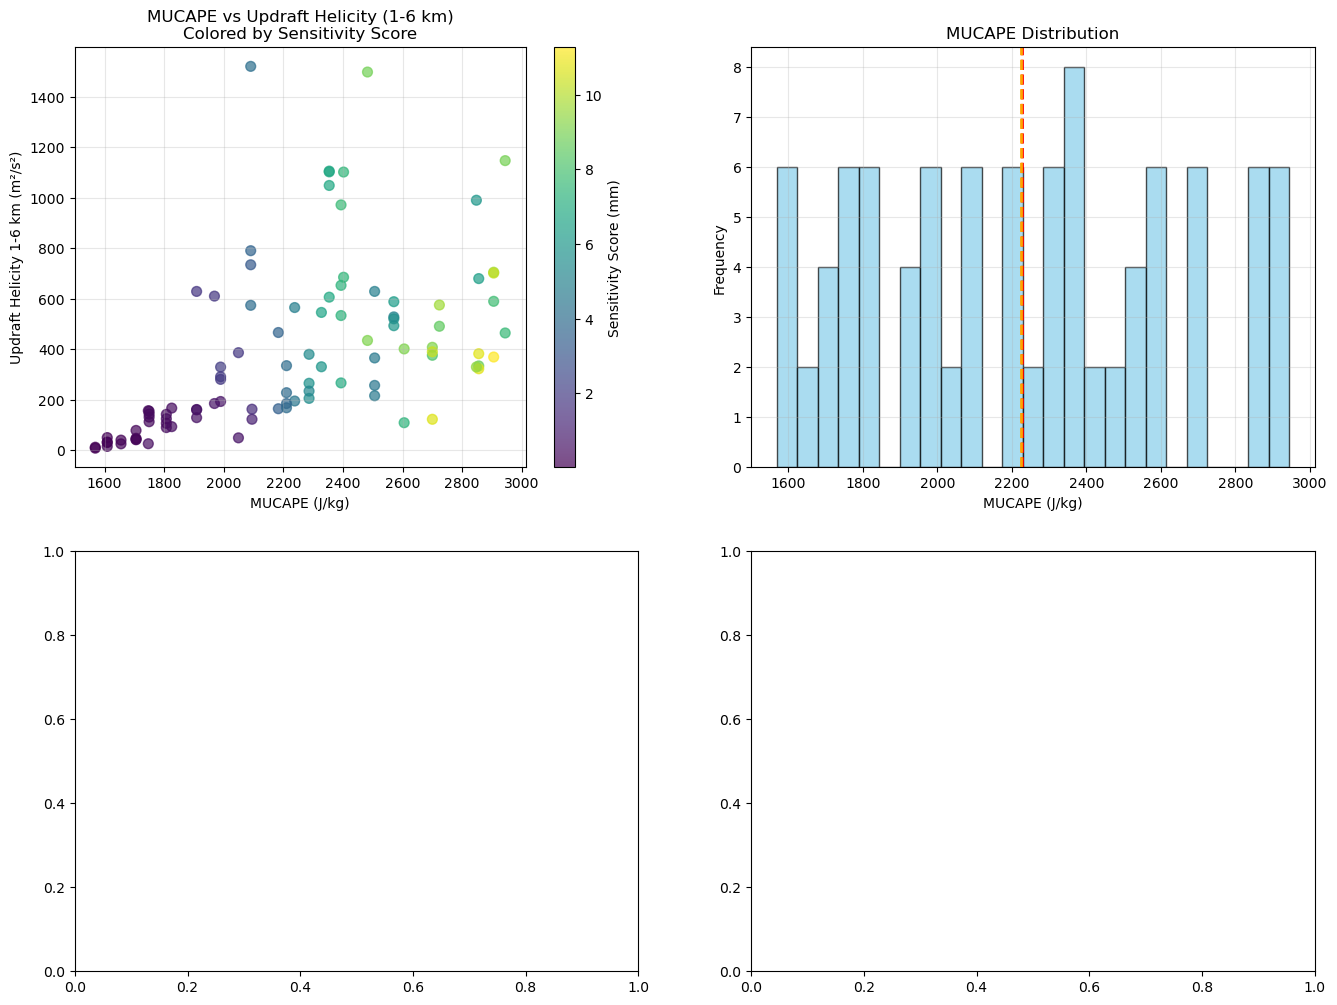

In [ ]:
if not df.empty and config.create_plots:
    print("📈 Creating MUCAPE vs Updraft Helicity visualizations...")
    
    # Check for required columns
    plot_cols = ['mucape', 'uh_1_6_peak', 'sensitivity_score', 'sbcape']
    available_plot_cols = [col for col in plot_cols if col in df.columns]
    
    if len(available_plot_cols) >= 3:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. MUCAPE vs UH 1-6 km colored by sensitivity
        valid_data = df[['mucape', 'uh_1_6_peak', 'sensitivity_score']].dropna()
        if len(valid_data) > 0:
            scatter = ax1.scatter(valid_data['mucape'], valid_data['uh_1_6_peak'], 
                                c=valid_data['sensitivity_score'], alpha=0.7, 
                                cmap='viridis', s=50)
            ax1.set_xlabel('MUCAPE (J/kg)')
            ax1.set_ylabel('Updraft Helicity 1-6 km (m²/s²)')
            ax1.set_title('MUCAPE vs Updraft Helicity (1-6 km)\nColored by Sensitivity Score')
            ax1.grid(True, alpha=0.3)
            cbar1 = plt.colorbar(scatter, ax=ax1)
            cbar1.set_label('Sensitivity Score (mm)')
        
        # 2. MUCAPE distribution
        mucape_data = df['mucape'].dropna()
        if len(mucape_data) > 0:
            ax2.hist(mucape_data, bins=25, alpha=0.7, edgecolor='black', color='skyblue')
            ax2.axvline(mucape_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {mucape_data.mean():.1f}')
            ax2.axvline(mucape_data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {mucape_data.median():.1f}')
            ax2.set_xlabel('MUCAPE (J/kg)')
            ax2.set_ylabel('Frequency')
            ax2.set_title('MUCAPE Distribution')
            ax2.grid(True, alpha=0.3)
            ax2.legend()
        # 3. Sensitivity vs MUCAPE
        if 'sensitivity_score' in df.columns:
            valid_data2 = df[['mucape', 'sensitivity_score']].dropna()
            if len(valid_data2) > 0:
                ax3.scatter(valid_data2['mucape'], valid_data2['sensitivity_score'], 
                            alpha=0.7, color='green', s=50)
                ax3.set_xlabel('MUCAPE (J/kg)')
                ax3.set_ylabel('Sensitivity Score (mm)')
                ax3.set_title('Sensitivity Score vs MUCAPE')
                ax3.grid(True, alpha=0.3)




